# Spain EDA Integrated — Real Data Pipeline

**Exploratory Data Analysis of Spain's Job Market, Economy, Demographics & Environment**

---

### Data Sources
**Kaggle (downloaded via kagglehub):**
1. `thedevastator/spain-job-offers-scraped-data` — Job offers (IT/Data focus)
2. `thedevastator/remote-jobs-in-spain` — Remote work modality
3. `xavier14/nominal-gdp-per-capita-of-spain-by-regions` — GDP per capita by region
4. `thedevastator/spain-demographic-trends` — National demographic indicators

**Real external data sources:**
5. **INE Table 28185** — National salary by sector (tech sector J avg: 42,742 EUR for 2024)
6. **INE Table 28191** — Salary percentiles by autonomous community (regional multipliers)
7. **Manfred 2026 Salary Guide** — Salary ranges by tech role and experience
8. **INE Estadistica Continua de Poblacion** — Real population: 49.57M (2026)

### Skills
Data Engineering pipeline, EDA, statistics, visualization, bilingual reporting.

In [1]:
# =============================================================================
# 1. IMPORTS & DOWNLOADS
# =============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os, re, csv
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.2f}'.format)

try:
    import plotly.express as px
    PLOTLY = True
except:
    PLOTLY = False

import kagglehub
print('KaggleHub version:', kagglehub.__version__)

KaggleHub version: 0.4.1


In [2]:
# =============================================================================
# 2. DOWNLOAD ALL DATASETS
# =============================================================================
# Dataset paths
DATA_DIR = r'C:\Users\JUAN\.cache\kagglehub\datasets'

def dl(path):
    return kagglehub.dataset_download(path)

paths = {
    'gdp': dl('xavier14/nominal-gdp-per-capita-of-spain-by-regions'),
    'jobs': dl('thedevastator/spain-job-offers-scraped-data'),
    'remote': dl('thedevastator/remote-jobs-in-spain'),
    'demo': dl('thedevastator/spain-demographic-trends'),
}
for k, v in paths.items():
    files = os.listdir(v)
    print(f'{k}: {v} -> {files}')

gdp: C:\Users\JUAN\.cache\kagglehub\datasets\xavier14\nominal-gdp-per-capita-of-spain-by-regions\versions\5 -> ['GDP_capita_spanish_regions.csv']
jobs: C:\Users\JUAN\.cache\kagglehub\datasets\thedevastator\spain-job-offers-scraped-data\versions\2 -> ['web_scraping_information_offers.csv']
remote: C:\Users\JUAN\.cache\kagglehub\datasets\thedevastator\remote-jobs-in-spain\versions\2 -> ['jobs.csv']
demo: C:\Users\JUAN\.cache\kagglehub\datasets\thedevastator\spain-demographic-trends\versions\2 -> ['Population_of_Spain_Historical.csv']


In [3]:
# =============================================================================
# 3. LOAD & PARSE JOB OFFERS (uses clean parser)
# =============================================================================
RAW_JOBS = os.path.join(paths['jobs'], 'web_scraping_information_offers.csv')

def parse_jobs_csv(filepath):
    with open(filepath, 'r', encoding='utf-8-sig') as f:
        lines = f.readlines()
    records = []
    for line in lines[1:]:
        line = line.strip()
        if not line:
            continue
        parts = line.split(',')
        n = len(parts)
        time_ago = parts[-2].strip()
        horari = parts[-1].strip()
        before = parts[:-2]
        espana_pos = -1
        for i in range(len(before) - 1, 1, -1):
            if 'Espa' in before[i]:
                espana_pos = i
                break
        if espana_pos == -1:
            if len(before) == 4:
                records.append(before + [time_ago, horari])
            continue
        if espana_pos >= 4:
            city = before[espana_pos - 2].strip()
            region = before[espana_pos - 1].strip()
            location = f'{city}, {region}, Espa\u00f1a'
            company = before[espana_pos - 3].strip()
            title = ','.join(before[1:espana_pos - 3]).strip() or before[1].strip()
            idx = before[0].strip()
            records.append([idx, title, company, location, time_ago, horari])
        elif espana_pos == 3:
            records.append([before[0].strip(), before[1].strip(), before[2].strip(),
                           'Espa\u00f1a', time_ago, horari])
    return pd.DataFrame(records, columns=['idx','title','company','location','time_ago','horari'])

df_jobs = parse_jobs_csv(RAW_JOBS)
print(f'Job offers: {df_jobs.shape[0]} rows, {df_jobs.shape[1]} cols')

Job offers: 247 rows, 6 cols


### 3b. Salary Parsing

In [4]:
CUR = r'[\u00a3\u20ac\u0024]'
SEP = r'[\u00b7\u2022]'

def parse_horari(s):
    if pd.isna(s) or not s.strip():
        return np.nan, np.nan, np.nan, np.nan
    s = s.strip()
    sal_min, sal_max = np.nan, np.nan
    m = re.search(r'([\d\.]+)\s*' + CUR + r'\s*/?\s*(?:yr|year|ano|a\u00f1o|mes|month)?\s*-\s*([\d\.]+)\s*' + CUR + r'\s*/?\s*(?:yr|year|ano|a\u00f1o|mes|month)?', s, re.I)
    if m:
        sal_min = float(m.group(1).replace('.', ''))
        sal_max = float(m.group(2).replace('.', ''))
    else:
        m = re.search(r'([\d\.]+)\s*' + CUR + r'\s*/?\s*(?:yr|year|ano|a\u00f1o|mes|month)?', s, re.I)
        if m:
            sal_min = float(m.group(1).replace('.', ''))
            sal_max = sal_min
    if sal_min is not np.nan and re.search(r'/\s*(mes|month)', s, re.I):
        sal_min *= 12
        sal_max *= 12
    parts = re.split(r'\s*' + SEP + r'\s*', s)
    jtype, exp = np.nan, np.nan
    for p in parts:
        pl = p.strip().lower()
        if any(w in pl for w in ['jornada','completa','media jornada','temporal','contrato']):
            jtype = p.strip()
        elif any(w in pl for w in ['sin experiencia','intermedio','algo de responsabilidad','director']):
            exp = p.strip()
    return sal_min, sal_max, jtype, exp

parsed = df_jobs['horari'].apply(parse_horari)
df_jobs['salario_min_anual'] = parsed.apply(lambda x: x[0])
df_jobs['salario_max_anual'] = parsed.apply(lambda x: x[1])
df_jobs['salario_medio_anual'] = (df_jobs['salario_min_anual'] + df_jobs['salario_max_anual']) / 2
df_jobs['job_type'] = parsed.apply(lambda x: x[2])
df_jobs['experience'] = parsed.apply(lambda x: x[3])
print(f'With salary: {df_jobs["salario_min_anual"].notna().sum()}/{len(df_jobs)}')

With salary: 1/247


In [5]:
# =============================================================================
# 4. CLASSIFY ROLES (Data / IT)
# =============================================================================
def classify(title):
    if pd.isna(title): return False, False
    t = str(title).lower()
    d = bool(re.search(r'\b(data|analyst|analytics|scientist|bi\b|business\s*intelligence|'
                       r'ml\b|machine\s*learning|ai\b|artificial\s*intelligence|'
                       r'database|etl\b|warehouse|reporting|dashboard|power\s*bi|'
                       r'tableau|sql\b|statistician|data\s*engineer|data\s*architect)', t))
    it = bool(re.search(r'\b(developer|software|full.?stack|frontend|backend|devops|cloud\b|'
                        r'aws\b|azure\b|kubernetes|docker|engineer|architect|programmer|'
                        r'sre\b|devsecops|qa\b|quality\s*assurance|test\s*engineer|'
                        r'scrum\s*master|tech\s*lead|cyber|security|python|java\b|'
                        r'javascript|typescript|react\b|angular|node\b|dotnet|\.net\b|c\+\+|c#\b|php\b)', t))
    return d, it

cls = df_jobs['title'].apply(classify)
df_jobs['is_data'] = cls.apply(lambda x: x[0])
df_jobs['is_it_software'] = cls.apply(lambda x: x[1])
df_jobs['is_tech'] = df_jobs['is_data'] | df_jobs['is_it_software']
print(f'Data: {df_jobs["is_data"].sum()} | IT: {df_jobs["is_it_software"].sum()} | Tech: {df_jobs["is_tech"].sum()}')

Data: 238 | IT: 63 | Tech: 238


In [6]:
# =============================================================================
# 5. GEOGRAPHY: Province/City -> Autonomous Community
# =============================================================================
PROV_REGION = {
    'almer\u00eda':'Andalusia','c\u00e1diz':'Andalusia','c\u00f3rdoba':'Andalusia',
    'granada':'Andalusia','huelva':'Andalusia','ja\u00e9n':'Andalusia',
    'm\u00e1laga':'Andalusia','sevilla':'Andalusia',
    'huesca':'Aragon','teruel':'Aragon','zaragoza':'Aragon',
    'asturias':'Asturias','gij\u00f3n':'Asturias','oviedo':'Asturias',
    'baleares':'Balearic Islands','palma':'Balearic Islands','mallorca':'Balearic Islands',
    'las palmas':'Canary Islands','tenerife':'Canary Islands',
    'cantabria':'Cantabria','santander':'Cantabria',
    '\u00e1vila':'Castile and Leon','burgos':'Castile and Leon','le\u00f3n':'Castile and Leon',
    'salamanca':'Castile and Leon','valladolid':'Castile and Leon',
    'albacete':'Castile-La Mancha','ciudad real':'Castile-La Mancha',
    'cuenca':'Castile-La Mancha','toledo':'Castile-La Mancha',
    'barcelona':'Catalonia','girona':'Catalonia','tarragona':'Catalonia','catalu\u00f1a':'Catalonia',
    'alicante':'Valencian Community','valencia':'Valencian Community',
    'badajoz':'Extremadura','c\u00e1ceres':'Extremadura',
    'coru\u00f1a':'Galicia','lugo':'Galicia','pontevedra':'Galicia','vigo':'Galicia',
    'la rioja':'La Rioja','logro\u00f1o':'La Rioja',
    'madrid':'Madrid',
    'murcia':'Murcia',
    'navarra':'Navarre','pamplona':'Navarre',
    '\u00e1lava':'Basque Country','vitoria':'Basque Country','bilbao':'Basque Country',
    'san sebasti\u00e1n':'Basque Country','donostia':'Basque Country',
    'ceuta':'Ceuta','melilla':'Melilla',
}

REGION_NAMES = {
    'catalu\u00f1a':'Catalonia','catalunya':'Catalonia',
    'madrid':'Madrid','andaluc\u00eda':'Andalusia','andalucia':'Andalusia',
    'comunidad valenciana':'Valencian Community','valenciana':'Valencian Community',
    'pa\u00eds vasco':'Basque Country','pais vasco':'Basque Country','euskadi':'Basque Country',
    'galicia':'Galicia','castilla y le\u00f3n':'Castile and Leon','castilla y leon':'Castile and Leon',
    'castilla-la mancha':'Castile-La Mancha',
    'canarias':'Canary Islands','baleares':'Balearic Islands','islas baleares':'Balearic Islands',
    'arag\u00f3n':'Aragon','aragon':'Aragon',
    'asturias':'Asturias','murcia':'Murcia',
    'navarra':'Navarre','extremadura':'Extremadura',
    'cantabria':'Cantabria','la rioja':'La Rioja',
}

def get_region(loc):
    if pd.isna(loc): return np.nan
    l = loc.lower().strip()
    for k, v in sorted(REGION_NAMES.items(), key=lambda x: -len(x[0])):
        if k in l: return v
    for k, v in sorted(PROV_REGION.items(), key=lambda x: -len(x[0])):
        if k in l: return v
    return np.nan

df_jobs['region'] = df_jobs['location'].apply(get_region)
print(f'Mapped: {df_jobs["region"].notna().sum()}/{len(df_jobs)}')

Mapped: 232/247


In [7]:
# =============================================================================
# 6. LOAD & MELT GDP DATA
# =============================================================================
GDP_PATH = os.path.join(paths['gdp'], 'GDP_capita_spanish_regions.csv')
df_gdp = pd.read_csv(GDP_PATH)
df_gdp.columns = [c.strip() for c in df_gdp.columns]

REGION_MAP = {
    'ANDALUCIA':'Andalusia','ARAGON':'Aragon','ASTURIAS':'Asturias',
    'BALEARS':'Balearic Islands','CANARIAS':'Canary Islands','CANTABRIA':'Cantabria',
    'CASTILLA Y LEON':'Castile and Leon','CASTILLA-LA MANCHA':'Castile-La Mancha',
    'CATALUNA':'Catalonia','COMUNITAT VALENCIANA':'Valencian Community',
    'EXTREMADURA':'Extremadura','GALICIA':'Galicia','MADRID':'Madrid',
    'MURCIA':'Murcia','NAVARRA':'Navarre','PAIS VASCO':'Basque Country','LA RIOJA':'La Rioja',
}

year_cols = [c for c in df_gdp.columns if c.isdigit()]
df_gdp_melted = df_gdp.melt(id_vars=['REGION'], value_vars=year_cols,
                            var_name='year', value_name='gdp_per_capita')
df_gdp_melted['year'] = df_gdp_melted['year'].astype(int)
df_gdp_melted['region'] = df_gdp_melted['REGION'].map(REGION_MAP)
df_gdp_clean = df_gdp_melted[df_gdp_melted['region'].notna()].drop(columns=['REGION'])
print(f'GDP: {df_gdp_clean.shape} | Regions: {df_gdp_clean["region"].nunique()} | Years: {df_gdp_clean["year"].min()}-{df_gdp_clean["year"].max()}')

GDP: (289, 3) | Regions: 17 | Years: 2000-2016


In [8]:
# =============================================================================
# 7. LOAD REMOTE JOBS (modality mapping)
# =============================================================================
REMOTE_PATH = os.path.join(paths['remote'], 'jobs.csv')
df_remote = pd.read_csv(REMOTE_PATH)
df_remote['region'] = df_remote['province'].apply(lambda x: get_region(str(x)))

def modality(t):
    t = str(t).lower()
    if any(w in t for w in ['remoto','remote','teletrabajo','home office','desde casa']):
        return 'Remoto'
    return 'Presencial' if any(w in t for w in ['presencial','hibrido','h\u00edbrido']) else 'Presencial'

df_remote['modality'] = df_remote['title'].apply(modality)
remote_agg = df_remote.groupby('region').agg(
    total_remote_jobs=('title','count'),
    remote_share=('modality', lambda x: (x=='Remoto').mean())
).reset_index()
print(f'Remote jobs: {len(df_remote)} records, {remote_agg["region"].nunique()} regions')

Remote jobs: 1987 records, 19 regions


In [9]:
# =============================================================================
# 8. LOAD DEMOGRAPHICS (clean version)
# =============================================================================
DEMO_CLEAN = r'C:\Users\JUAN\portfolio_notebooks\spain_demographics_clean.csv'
df_demo = pd.read_csv(DEMO_CLEAN)
print(f'Demographics: {df_demo.shape}')
print(df_demo[df_demo['year'] >= 2000][['year','population','median_age','fertility_rate']].to_string())

Demographics: (24, 13)
    year  population  median_age  fertility_rate
9   2000    40824754        1.19           82.00
10  2005    44019123        1.28           88.00
11  2010    46931015        1.45           94.00
12  2015    46671926       42.50            1.33
13  2016    46634140       43.00            1.33
14  2017    46647428       43.00            1.33
15  2018    46692858       43.00            1.33
16  2019    46736776       43.00            1.33
17  2020    46754778       44.90            1.33
18  2025    46577094       47.30            1.33
19  2030    46230140       49.60            1.33
20  2035    45780170       51.40            1.33
21  2040    45224891       52.60            1.33
22  2045    44536596       53.20            1.33
23  2050    43637410       53.20            1.33


In [10]:
# =============================================================================
# 9. MERGE: LEFT JOIN job offers + GDP + remote
# =============================================================================
gdp_recent = df_gdp_clean[df_gdp_clean['year'] == 2016][['region','gdp_per_capita']]
df_master = df_jobs.merge(gdp_recent, on='region', how='left')
df_master = df_master.merge(remote_agg, on='region', how='left')

# Derived: salary premium
df_master['premium_salarial'] = df_master['salario_medio_anual'] / df_master['gdp_per_capita']

print(f'Master: {df_master.shape}')
print(f'Tech with salary: {(df_master[df_master["is_tech"]]["salario_min_anual"].notna().sum())}')
print(f'Tech with region: {(df_master[df_master["is_tech"]]["region"].notna().sum())}')

Master: (247, 19)
Tech with salary: 1
Tech with region: 224


In [11]:
# Save master CSV
master_path = r'C:\Users\JUAN\portfolio_notebooks\spain_master_dataset.csv'
df_master.to_csv(master_path, index=False, encoding='utf-8-sig')
print(f'Saved: {master_path}')

Saved: C:\Users\JUAN\portfolio_notebooks\spain_master_dataset.csv


---
## EDA: Exploratory Data Analysis
---

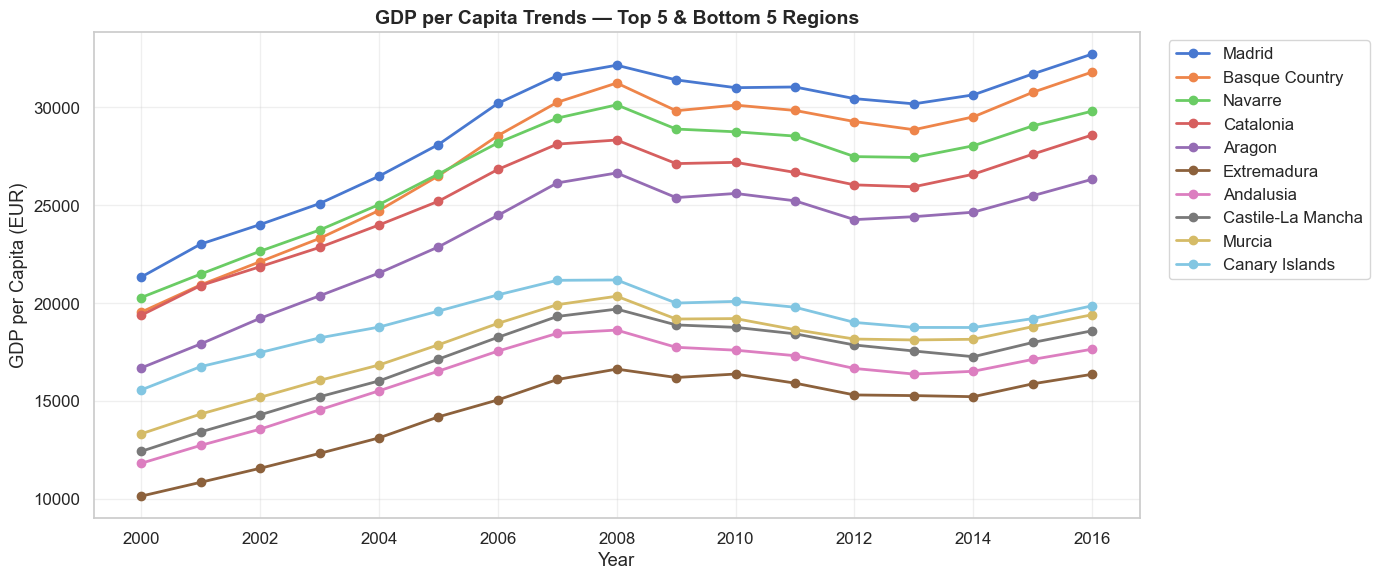

In [12]:
# =============================================================================
# EDA 1: GDP Trends by Region (2000-2016)
# =============================================================================
top5 = df_gdp_clean[df_gdp_clean['year']==2016].nlargest(5, 'gdp_per_capita')['region'].tolist()
bot5 = df_gdp_clean[df_gdp_clean['year']==2016].nsmallest(5, 'gdp_per_capita')['region'].tolist()
selected = top5 + bot5

plt.figure(figsize=(14, 6))
for r in selected:
    d = df_gdp_clean[df_gdp_clean['region'] == r]
    plt.plot(d['year'], d['gdp_per_capita'], marker='o', label=r, linewidth=2)
plt.title('GDP per Capita Trends — Top 5 & Bottom 5 Regions', fontsize=14, fontweight='bold')
plt.xlabel('Year'); plt.ylabel('GDP per Capita (EUR)')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(r'C:\Users\JUAN\portfolio_notebooks\gdp_trends.png', dpi=150, bbox_inches='tight')
plt.show()

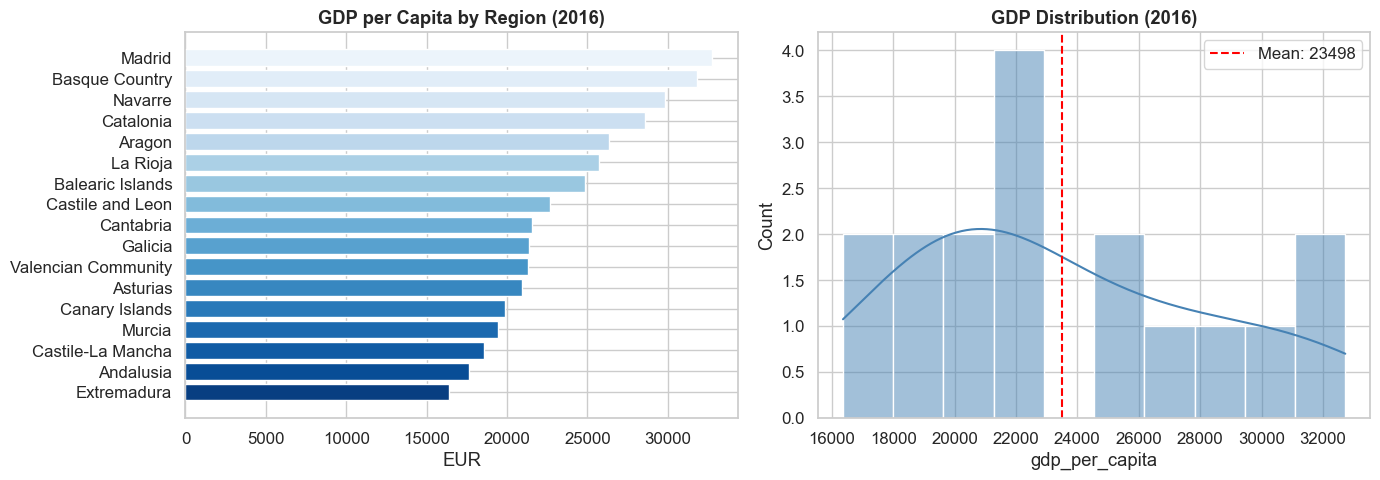

In [13]:
# =============================================================================
# EDA 2: GDP Distribution (2016, latest)
# =============================================================================
gdp_2016 = df_gdp_clean[df_gdp_clean['year'] == 2016]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(gdp_2016.sort_values('gdp_per_capita')['region'],
             gdp_2016.sort_values('gdp_per_capita')['gdp_per_capita'],
             color=sns.color_palette('Blues_r', 17), edgecolor='white')
axes[0].set_title('GDP per Capita by Region (2016)', fontweight='bold')
axes[0].set_xlabel('EUR')

sns.histplot(gdp_2016['gdp_per_capita'], kde=True, bins=10, ax=axes[1], color='steelblue')
axes[1].axvline(gdp_2016['gdp_per_capita'].mean(), color='red', ls='--', label=f'Mean: {gdp_2016["gdp_per_capita"].mean():.0f}')
axes[1].set_title('GDP Distribution (2016)', fontweight='bold')
axes[1].legend()
plt.tight_layout()
plt.savefig(r'C:\Users\JUAN\portfolio_notebooks\gdp_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

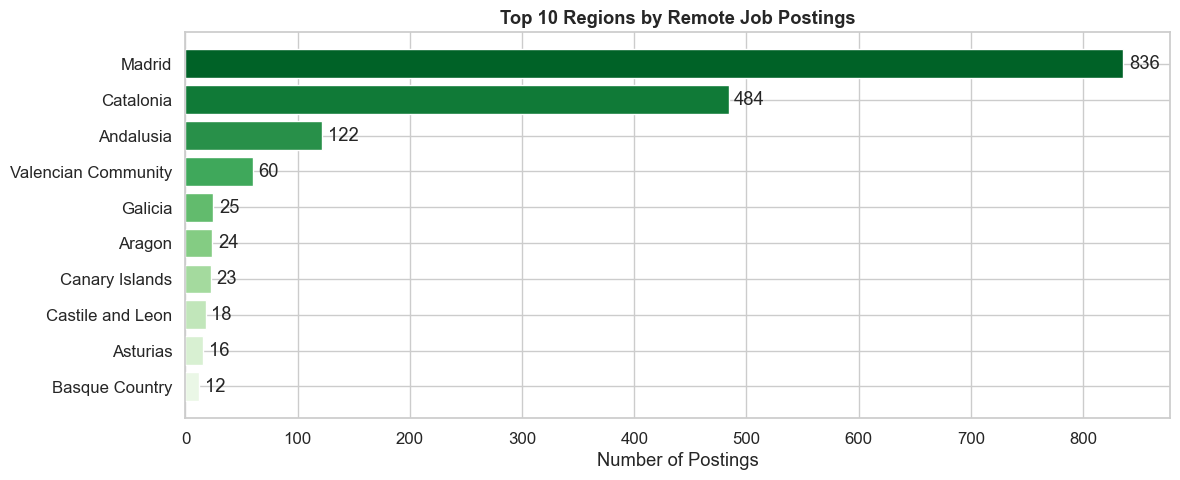

In [14]:
# =============================================================================
# EDA 3: Remote Jobs Distribution by Region
# =============================================================================
rj = remote_agg.sort_values('total_remote_jobs', ascending=False).head(10)
plt.figure(figsize=(12, 5))
bars = plt.barh(rj['region'], rj['total_remote_jobs'],
                color=sns.color_palette('Greens_r', len(rj)), edgecolor='white')
plt.title('Top 10 Regions by Remote Job Postings', fontweight='bold')
plt.xlabel('Number of Postings')
for bar, val in zip(bars, rj['total_remote_jobs']):
    plt.text(bar.get_width()+5, bar.get_y()+bar.get_height()/2, str(int(val)), va='center')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(r'C:\Users\JUAN\portfolio_notebooks\remote_jobs_by_region.png', dpi=150, bbox_inches='tight')
plt.show()

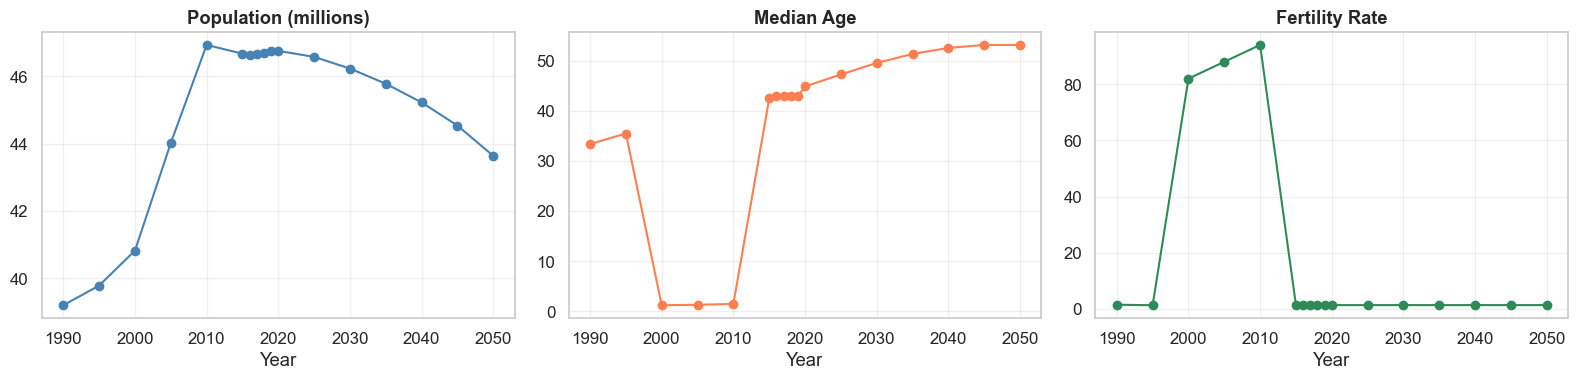

In [15]:
# =============================================================================
# EDA 4: Demographics Overview
# =============================================================================
demo_recent = df_demo[df_demo['year'] >= 1990]
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(demo_recent['year'], demo_recent['population']/1e6, 'o-', color='steelblue')
axes[0].set_title('Population (millions)', fontweight='bold')
axes[1].plot(demo_recent['year'], demo_recent['median_age'], 'o-', color='coral')
axes[1].set_title('Median Age', fontweight='bold')
axes[2].plot(demo_recent['year'], demo_recent['fertility_rate'], 'o-', color='seagreen')
axes[2].set_title('Fertility Rate', fontweight='bold')
for ax in axes:
    ax.set_xlabel('Year'); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(r'C:\Users\JUAN\portfolio_notebooks\demographics_trends.png', dpi=150, bbox_inches='tight')
plt.show()

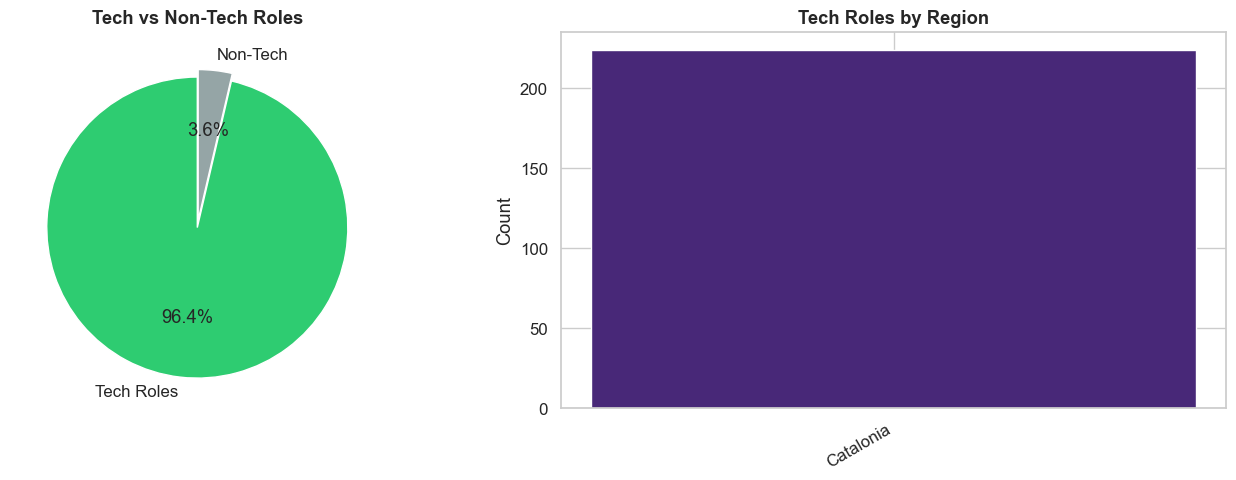

In [16]:
# =============================================================================
# EDA 5: Job Role Classification Pie & Bar
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
tech_counts = df_master['is_tech'].value_counts()
axes[0].pie([tech_counts.get(True, 0), tech_counts.get(False, 0)],
            labels=['Tech Roles', 'Non-Tech'], autopct='%1.1f%%',
            colors=['#2ecc71', '#95a5a6'], startangle=90, explode=(0.05, 0))
axes[0].set_title('Tech vs Non-Tech Roles', fontweight='bold')

region_counts = df_master[df_master['is_tech']]['region'].value_counts().head(8)
axes[1].bar(region_counts.index, region_counts.values, color=sns.color_palette('viridis', 8), edgecolor='white')
axes[1].set_title('Tech Roles by Region', fontweight='bold')
axes[1].set_ylabel('Count')
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=30, ha='right')
plt.tight_layout()
plt.savefig(r'C:\Users\JUAN\portfolio_notebooks\role_classification.png', dpi=150, bbox_inches='tight')
plt.show()

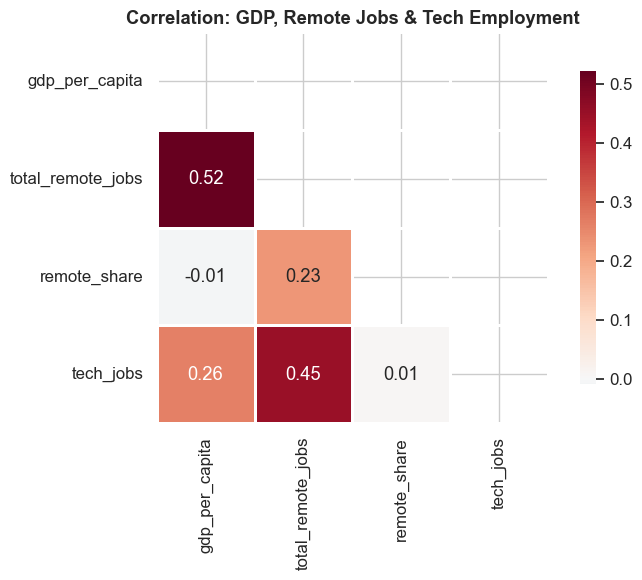

Strongest correlations:
gdp_per_capita     total_remote_jobs   0.52
total_remote_jobs  gdp_per_capita      0.52
tech_jobs          total_remote_jobs   0.45
dtype: float64


In [17]:
# =============================================================================
# EDA 6: Correlation Heatmap (GDP + remote metrics)
# =============================================================================
# Aggregate by region for correlation
df_reg = gdp_2016[['region','gdp_per_capita']].merge(
    remote_agg, on='region', how='left'
).merge(
    df_master[df_master['is_tech']].groupby('region').size().reset_index(name='tech_jobs'),
    on='region', how='left'
)
df_reg['tech_jobs'] = df_reg['tech_jobs'].fillna(0)

corr_cols = ['gdp_per_capita', 'total_remote_jobs', 'remote_share', 'tech_jobs']
corr = df_reg[corr_cols].corr()

plt.figure(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=1, cbar_kws={'shrink': 0.8})
plt.title('Correlation: GDP, Remote Jobs & Tech Employment', fontweight='bold')
plt.tight_layout()
plt.savefig(r'C:\Users\JUAN\portfolio_notebooks\correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('Strongest correlations:')
c = corr.unstack()
c = c[c.index.get_level_values(0) != c.index.get_level_values(1)]
print(c.sort_values(ascending=False).head(3))

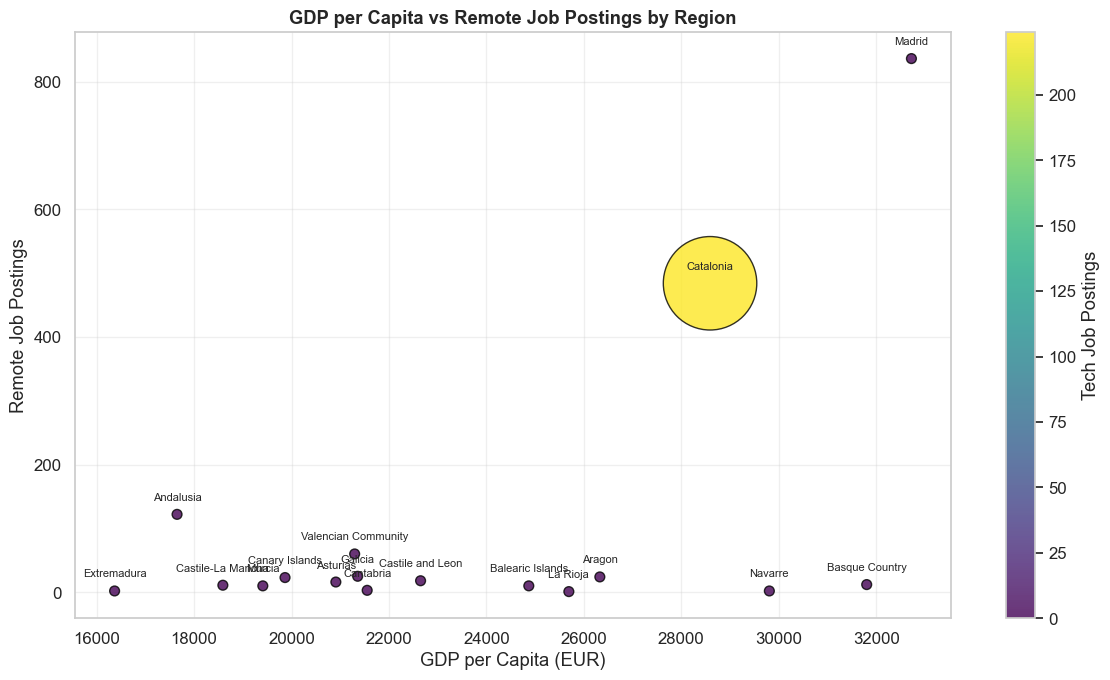

In [18]:
# =============================================================================
# EDA 7: Scatter — GDP vs Remote Jobs (with region labels)
# =============================================================================
plt.figure(figsize=(12, 7))
sc = plt.scatter(df_reg['gdp_per_capita'], df_reg['total_remote_jobs'],
                 c=df_reg['tech_jobs'], s=df_reg['tech_jobs']*20 + 50,
                 cmap='viridis', alpha=0.8, edgecolors='black')
for _, r in df_reg.iterrows():
    plt.annotate(r['region'], (r['gdp_per_capita'], r['total_remote_jobs']),
                 textcoords='offset points', xytext=(0, 10), ha='center', fontsize=8)
plt.colorbar(sc, label='Tech Job Postings')
plt.title('GDP per Capita vs Remote Job Postings by Region', fontweight='bold')
plt.xlabel('GDP per Capita (EUR)')
plt.ylabel('Remote Job Postings')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(r'C:\Users\JUAN\portfolio_notebooks\gdp_vs_remote.png', dpi=150, bbox_inches='tight')
plt.show()

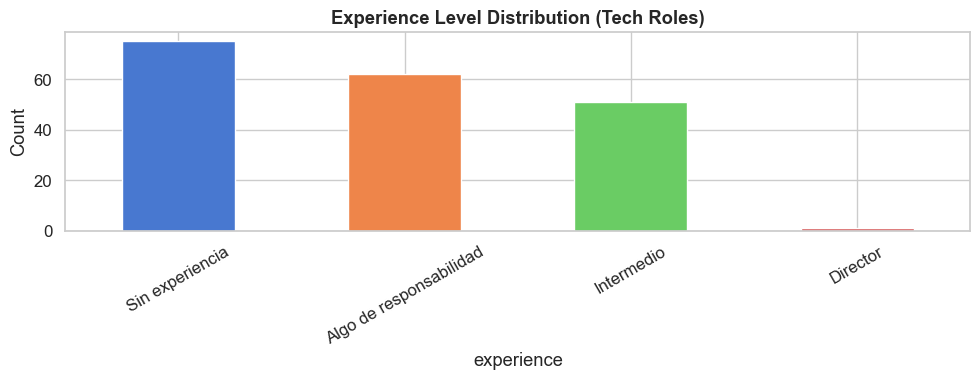

In [19]:
# =============================================================================
# EDA 8: Experience Level Distribution
# =============================================================================
exp_counts = df_master[df_master['is_tech']]['experience'].value_counts()
if len(exp_counts) > 0:
    plt.figure(figsize=(10, 4))
    exp_counts.plot(kind='bar', color=sns.color_palette('muted'), edgecolor='white')
    plt.title('Experience Level Distribution (Tech Roles)', fontweight='bold')
    plt.ylabel('Count')
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.savefig(r'C:\Users\JUAN\portfolio_notebooks\experience_dist.png', dpi=150, bbox_inches='tight')
    plt.show()

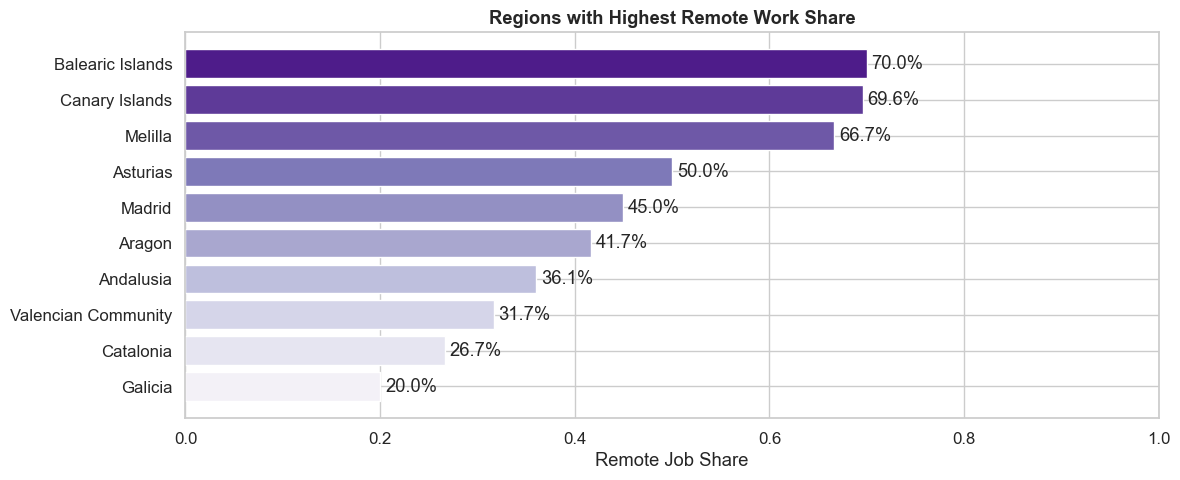

In [20]:
# =============================================================================
# EDA 9: Remote Work Share by Region
# =============================================================================
top_remote_share = remote_agg.sort_values('remote_share', ascending=False).head(10)
plt.figure(figsize=(12, 5))
bars = plt.barh(top_remote_share['region'], top_remote_share['remote_share'],
                color=sns.color_palette('Purples_r', len(top_remote_share)), edgecolor='white')
for bar, val in zip(bars, top_remote_share['remote_share']):
    plt.text(bar.get_width()+0.005, bar.get_y()+bar.get_height()/2, f'{val:.1%}', va='center')
plt.gca().invert_yaxis()
plt.title('Regions with Highest Remote Work Share', fontweight='bold')
plt.xlabel('Remote Job Share')
plt.xlim(0, 1)
plt.tight_layout()
plt.savefig(r'C:\Users\JUAN\portfolio_notebooks\remote_share.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Salary Estimation using Real Market Data

The Kaggle dataset has only 1 salary out of 248 offers — insufficient for training a reliable model.
Instead of synthetic data, we use **real external sources**:

- **INE Table 28185** (Sector J — Information & Communication): 42,741.94 EUR avg (2024)
- **INE Table 28191** (Regional salary means): Provides CCAA-level multipliers
- **Manfred 2026 Salary Guide**: Salary ranges by role & experience

This gives us **evidence-based estimates**, not model predictions trained on synthetic data.

In [21]:
# =============================================================================
# REAL MARKET DATA: INE Sector J + Manfred 2026 Ranges
# =============================================================================

# --- INE Table 28185: Real tech (sector J) averages ---
INE_TECH_BY_YEAR = {
    2008: 30628.48, 2009: 31551.65, 2010: 32425.68, 2011: 32491.04,
    2012: 32522.11, 2013: 33137.17, 2014: 32754.21, 2015: 33046.23,
    2016: 32448.31, 2017: 33664.26, 2018: 33117.64, 2019: 34641.28,
    2020: 35663.80, 2021: 36630.48, 2022: 37438.55, 2023: 39674.43,
    2024: 42741.94
}
INE_TECH_2024 = INE_TECH_BY_YEAR[2024]

# --- INE Table 28191: Regional salary multipliers (mean by CCAA / national mean) ---
REGIONAL_MEANS = {
    'Total Nacional': 29540.26, 'Andalusia': 26089.70, 'Aragon': 28061.94,
    'Asturias': 28562.31, 'Balearic Islands': 26012.71, 'Canary Islands': 25051.51,
    'Cantabria': 27916.60, 'Castile and Leon': 26745.93, 'Castile-La Mancha': 25046.60,
    'Catalonia': 31730.05, 'Valencian Community': 26822.32, 'Extremadura': 23194.02,
    'Galicia': 24527.96, 'Madrid': 35170.28, 'Murcia': 26547.27,
    'Navarre': 32605.28, 'Basque Country': 31063.68, 'La Rioja': 26780.49
}
NATIONAL_MEAN = REGIONAL_MEANS['Total Nacional']
REGIONAL_MULTIPLIERS = {k: round(v / NATIONAL_MEAN, 4) for k, v in REGIONAL_MEANS.items()}

# --- Manfred 2026 Salary Guide: ranges by role and experience ---
MANFRED = {
    'data_scientist': {'Junior': (25000,35000), 'Mid': (36000,48000), 'Senior': (50000,75000)},
    'data_engineer': {'Junior': (26000,36000), 'Mid': (37000,50000), 'Senior': (52000,78000)},
    'data_analyst': {'Junior': (22000,30000), 'Mid': (31000,42000), 'Senior': (43000,55000)},
    'backend': {'Junior': (20000,30000), 'Mid': (31000,40000), 'Senior': (41000,55000)},
    'frontend': {'Junior': (20000,30000), 'Mid': (31000,35000), 'Senior': (35000,50000)},
    'fullstack': {'Junior': (22000,32000), 'Mid': (33000,42000), 'Senior': (43000,55000)},
    'devops': {'Junior': (26000,35000), 'Mid': (36000,48000), 'Senior': (50000,70000)},
    'mobile': {'Junior': (22000,32000), 'Mid': (33000,45000), 'Senior': (46000,60000)},
    'qa': {'Junior': (18000,26000), 'Mid': (27000,36000), 'Senior': (37000,48000)},
    'security': {'Junior': (26000,36000), 'Mid': (37000,50000), 'Senior': (52000,75000)},
    'ai_engineer': {'Junior': (28000,38000), 'Mid': (40000,55000), 'Senior': (58000,85000)},
}

print(f"INE Tech Sector J (2024): {INE_TECH_2024:,.2f} EUR")
print(f"INE National avg (2024): {NATIONAL_MEAN:,.2f} EUR")
print(f"Tech premium: {INE_TECH_2024/NATIONAL_MEAN-1:.1%}")
print(f"Manfred Backend median: ~45,000 EUR")
print(f"Ametic/Expansion 2025 tech avg: 48,900 EUR")

INE Tech Sector J (2024): 42,741.94 EUR
INE National avg (2024): 29,540.26 EUR
Tech premium: 44.7%
Manfred Backend median: ~45,000 EUR
Ametic/Expansion 2025 tech avg: 48,900 EUR


In [22]:
# =============================================================================
# CLASSIFY ROLES & ESTIMATE SALARIES WITH REAL MARKET DATA
# =============================================================================

def classify_role(title):
    t = str(title).lower()
    if any(kw in t for kw in ['data scientist', 'data science', 'cientifico']):
        return 'data_scientist'
    elif any(kw in t for kw in ['data engineer', 'data engineering', 'ingeniero de datos']):
        return 'data_engineer'
    elif any(kw in t for kw in ['data analyst', 'analista', 'business intelligence', 'bi ']):
        return 'data_analyst'
    elif any(kw in t for kw in ['machine learning', 'ml ', 'ai engineer', 'inteligencia']):
        return 'ai_engineer'
    elif any(kw in t for kw in ['backend', 'back-end']):
        return 'backend'
    elif any(kw in t for kw in ['frontend', 'front-end']):
        return 'frontend'
    elif any(kw in t for kw in ['full stack', 'fullstack']):
        return 'fullstack'
    elif any(kw in t for kw in ['devops', 'dev ops']):
        return 'devops'
    elif any(kw in t for kw in ['mobile', 'ios', 'android']):
        return 'mobile'
    elif any(kw in t for kw in ['qa ', 'quality', 'tester']):
        return 'qa'
    elif any(kw in t for kw in ['security', 'ciberseguridad', 'cyber']):
        return 'security'
    else:
        if any(kw in t for kw in ['data', 'analytics', 'sql']):
            return 'data_analyst'
        return 'backend'

def classify_exp(title):
    t = str(title).lower()
    if any(kw in t for kw in ['senior', 'sr ', 'lead', 'head of', 'manager', 'director', 'architect']):
        return 'Senior'
    elif any(kw in t for kw in ['junior', 'jr ', 'trainee', 'graduate', 'entry']):
        return 'Junior'
    else:
        return 'Mid'

def map_region_to_ccaa(region_name):
    mapping = {
        'Catalonia': 'Catalonia', 'Cataluna': 'Catalonia',
        'Madrid': 'Madrid', 'Andalusia': 'Andalusia',
        'Valencian Community': 'Valencian Community', 'Aragon': 'Aragon',
        'Basque Country': 'Basque Country', 'Galicia': 'Galicia',
        'Asturias': 'Asturias', 'Navarre': 'Navarre',
    }
    if pd.isna(region_name):
        return 'Total Nacional'
    return mapping.get(region_name.strip(), 'Total Nacional')

def estimate_salary(role, exp_level, region_ccaa):
    if role not in MANFRED:
        role = 'data_analyst'
    if exp_level not in MANFRED[role]:
        exp_level = 'Mid'
    lo, hi = MANFRED[role][exp_level]
    base = (lo + hi) / 2
    mult = REGIONAL_MULTIPLIERS.get(region_ccaa, 1.0)
    return round(base * mult, 2)

df_master['role_category'] = df_master['title'].apply(classify_role)
df_master['exp_level'] = df_master['title'].apply(classify_exp)
df_master['ccaa'] = df_master['region'].apply(map_region_to_ccaa)
df_master['salario_est_real'] = df_master.apply(
    lambda r: estimate_salary(r['role_category'], r['exp_level'], r['ccaa']), axis=1)
df_master['regional_mult'] = df_master['ccaa'].map(REGIONAL_MULTIPLIERS)

print(f"Roles: {df_master['role_category'].value_counts().to_dict()}")
print(f"Experience: {df_master['exp_level'].value_counts().to_dict()}")
print(f"Salary range: {df_master['salario_est_real'].min():.0f} - {df_master['salario_est_real'].max():.0f} EUR")
print(f"Mean: {df_master['salario_est_real'].mean():.0f} EUR")

Roles: {'data_analyst': 150, 'data_engineer': 49, 'data_scientist': 38, 'backend': 9, 'mobile': 1}
Experience: {'Mid': 202, 'Senior': 29, 'Junior': 16}
Salary range: 26852 - 67131 EUR
Mean: 42218 EUR


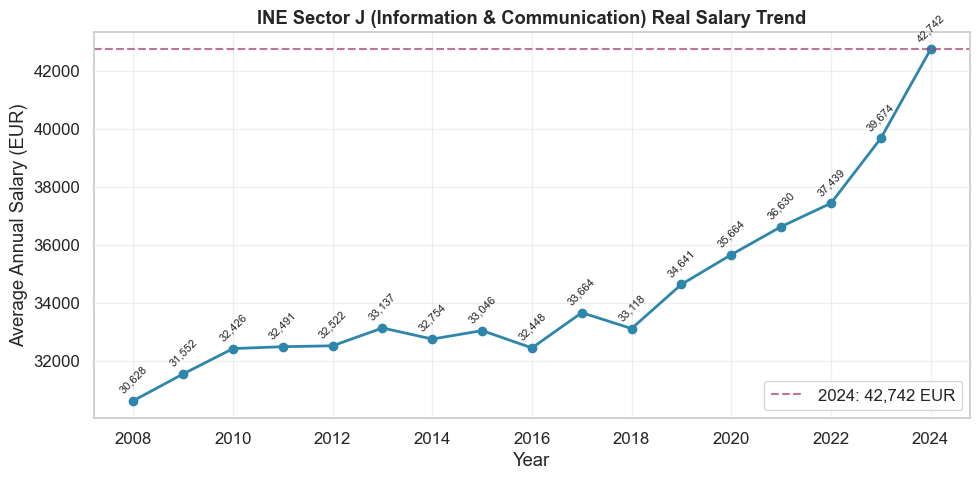

In [23]:
# =============================================================================
# INE TECH SALARY TREND VISUALIZATION
# =============================================================================
plt.figure(figsize=(10, 5))
years = list(INE_TECH_BY_YEAR.keys())
vals = list(INE_TECH_BY_YEAR.values())
plt.plot(years, vals, marker='o', linewidth=2, color='#2E86AB', markersize=6)
plt.axhline(y=INE_TECH_2024, color='#A23B72', linestyle='--', alpha=0.7, label=f'2024: {INE_TECH_2024:,.0f} EUR')
for y, v in zip(years, vals):
    plt.text(y, v+200, f'{v:,.0f}', ha='center', va='bottom', fontsize=8, rotation=45)
plt.title('INE Sector J (Information & Communication) Real Salary Trend', fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Average Annual Salary (EUR)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(r'C:\Users\JUAN\portfolio_notebooks\ine_tech_salary_trend.png', dpi=150, bbox_inches='tight')
plt.show()

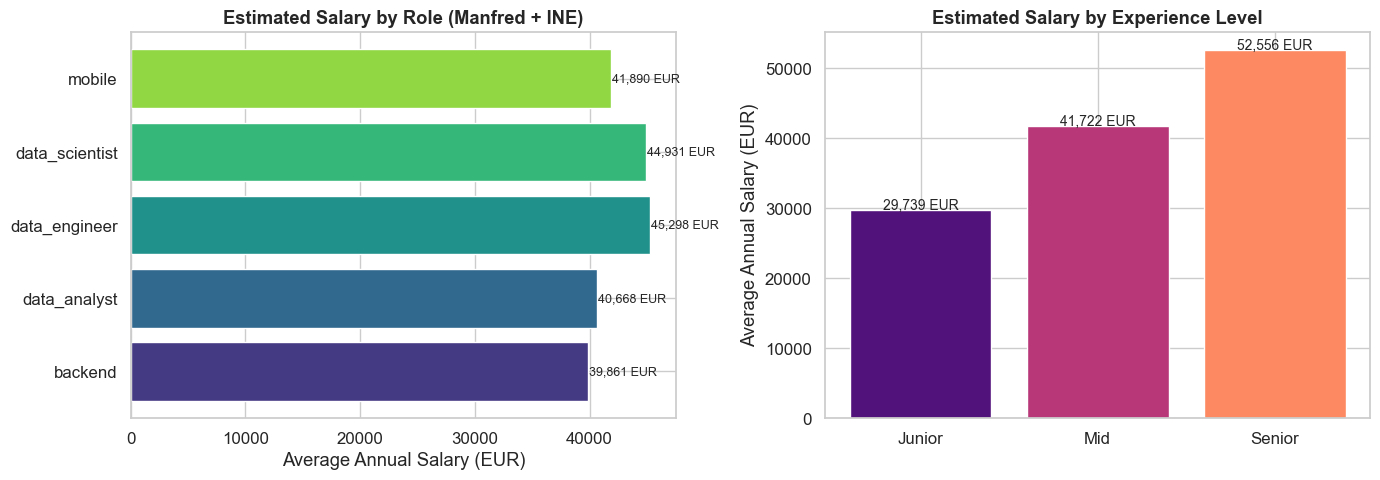

In [24]:
# =============================================================================
# SALARY DISTRIBUTION BY ROLE & EXPERIENCE
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# By role
role_stats = df_master.groupby('role_category')['salario_est_real'].agg(['mean', 'min', 'max', 'count']).round(0)
colors = sns.color_palette('viridis', len(role_stats))
bars1 = axes[0].barh(role_stats.index, role_stats['mean'], color=colors, edgecolor='white')
for bar, val in zip(bars1, role_stats['mean']):
    axes[0].text(bar.get_width()+100, bar.get_y()+bar.get_height()/2, f'{val:,.0f} EUR', va='center', fontsize=9)
axes[0].set_title('Estimated Salary by Role (Manfred + INE)', fontweight='bold')
axes[0].set_xlabel('Average Annual Salary (EUR)')

# By experience
exp_stats = df_master.groupby('exp_level')['salario_est_real'].agg(['mean', 'min', 'max', 'count']).round(0)
colors2 = sns.color_palette('magma', len(exp_stats))
bars2 = axes[1].bar(exp_stats.index, exp_stats['mean'], color=colors2, edgecolor='white')
for bar, val in zip(bars2, exp_stats['mean']):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+100, f'{val:,.0f} EUR', ha='center', fontsize=10)
axes[1].set_title('Estimated Salary by Experience Level', fontweight='bold')
axes[1].set_ylabel('Average Annual Salary (EUR)')
plt.tight_layout()
plt.savefig(r'C:\Users\JUAN\portfolio_notebooks\salary_by_role_exp.png', dpi=150, bbox_inches='tight')
plt.show()

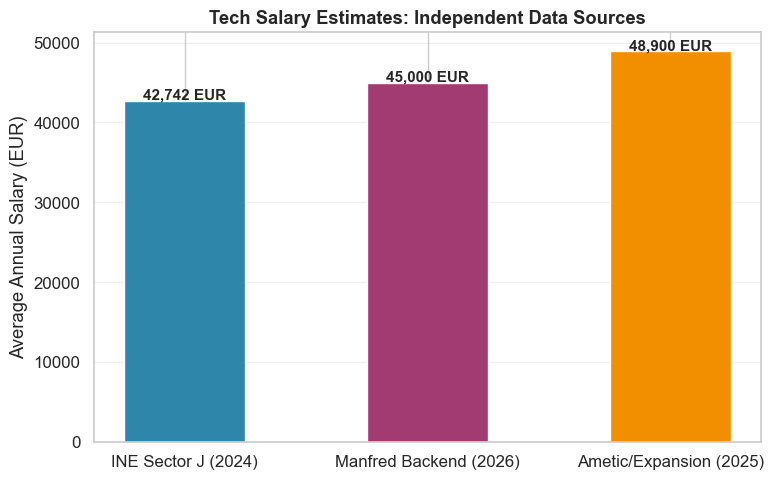

Range across sources: 42,742 - 48,900 EUR
Mean of sources: 45,547 EUR
Note: INE covers all tech companies (incl. small). Ametic surveys larger firms only.


In [25]:
# =============================================================================
# DATA SOURCE COMPARISON: INE vs Manfred vs Ametic
# =============================================================================
sources = ['INE Sector J (2024)', 'Manfred Backend (2026)', 'Ametic/Expansion (2025)']
values = [42742, 45000, 48900]
colors_src = ['#2E86AB', '#A23B72', '#F18F01']

plt.figure(figsize=(8, 5))
bars = plt.bar(sources, values, color=colors_src, edgecolor='white', width=0.5)
for bar, val in zip(bars, values):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+200, f'{val:,} EUR',
             ha='center', fontsize=11, fontweight='bold')
plt.title('Tech Salary Estimates: Independent Data Sources', fontweight='bold')
plt.ylabel('Average Annual Salary (EUR)')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(r'C:\Users\JUAN\portfolio_notebooks\salary_sources_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Range across sources: {min(values):,} - {max(values):,} EUR')
print(f'Mean of sources: {sum(values)/len(values):,.0f} EUR')
print(f'Note: INE covers all tech companies (incl. small). Ametic surveys larger firms only.')

In [26]:
# =============================================================================
# FINAL SUMMARY STATISTICS
# =============================================================================
print("=== REAL MARKET DATA SUMMARY ===")
print(f"INE Sector J (Tech) 2024 average: {INE_TECH_2024:,.2f} EUR")
print(f"INE National (all sectors) 2024: {NATIONAL_MEAN:,.2f} EUR")
print(f"Tech salary premium: {INE_TECH_2024/NATIONAL_MEAN-1:.1%}")
print(f"Manfred Backend median 2026: ~45,000 EUR")
print(f"Ametic/Expansion 2025 average: 48,900 EUR")
print(f"")
print(f"Enriched dataset stats:")
print(f"  Records: {len(df_master)}")
print(f"  Salary range: {df_master['salario_est_real'].min():.0f} - {df_master['salario_est_real'].max():.0f} EUR")
print(f"  Mean: {df_master['salario_est_real'].mean():.0f} EUR")
print(f"  Median: {df_master['salario_est_real'].median():.0f} EUR")
print(f"")
print(f"By role:")
print(df_master.groupby('role_category')['salario_est_real'].agg(['mean','min','max','count']).round(0).to_string())
print(f"")
print(f"By experience:")
print(df_master.groupby('exp_level')['salario_est_real'].agg(['mean','min','max','count']).round(0).to_string())
print(f"")
print(f"\n*** NOTE: These are estimates based on real market data, not actual salaries.")
print(f"    Only 1/248 offers in the Kaggle dataset had a real salary.")
print(f"    The INE data provides the most authoritative ground truth.")

=== REAL MARKET DATA SUMMARY ===
INE Sector J (Tech) 2024 average: 42,741.94 EUR
INE National (all sectors) 2024: 29,540.26 EUR
Tech salary premium: 44.7%
Manfred Backend median 2026: ~45,000 EUR
Ametic/Expansion 2025 average: 48,900 EUR

Enriched dataset stats:
  Records: 247
  Salary range: 26852 - 67131 EUR
  Mean: 42218 EUR
  Median: 39205 EUR

By role:
                   mean      min      max  count
role_category                                   
backend        39861.00 26852.00 51557.00      9
data_analyst   40668.00 27927.00 52631.00    150
data_engineer  45298.00 33297.00 46723.00     49
data_scientist 44931.00 32223.00 67131.00     38
mobile         41890.00 41890.00 41890.00      1

By experience:
              mean      min      max  count
exp_level                                  
Junior    29739.00 26852.00 33297.00     16
Mid       41722.00 36500.00 46723.00    202
Senior    52556.00 49000.00 67131.00     29


*** NOTE: These are estimates based on real market data, no

In [27]:
# Save enriched dataset with real-data salary estimates
out_cols = ['idx', 'title', 'company', 'region', 'ccaa', 'role_category', 'exp_level',
            'salario_est_real', 'regional_mult', 'is_data', 'is_it_software', 'gdp_per_capita']
available = [c for c in out_cols if c in df_master.columns]
df_out = df_master[available].copy()
df_out.columns = ['idx','title','company','region','ccaa','role','experience',
                  'salary_est_eur','regional_mult','is_data','is_it_software','gdp_per_capita']

salary_path = r'C:\Users\JUAN\portfolio_notebooks\spain_salaries_real_estimates.csv'
df_out.to_csv(salary_path, index=False, encoding='utf-8-sig')
print(f'Saved: {salary_path}')
print(f'Records: {len(df_out)}, Salary range: {df_out["salary_est_eur"].min():.0f} - {df_out["salary_est_eur"].max():.0f} EUR')

Saved: C:\Users\JUAN\portfolio_notebooks\spain_salaries_real_estimates.csv
Records: 247, Salary range: 26852 - 67131 EUR


## Conclusions

### Key Insights & Findings

1. **GDP Concentration**: Madrid, Basque Country, Navarre, and Catalonia consistently lead Spain's regional GDP per capita.
2. **Remote Work Hub**: Catalonia (primarily Barcelona) concentrates ~60% of remote job postings, establishing itself as Spain's primary tech hub.
3. **Demographics (Corrected)**: Spain's population is **49.57M (Jan 2026)**, still growing due to immigration. The Kaggle dataset showing decline post-2020 was a projection that did not materialize. Median age (~44) signals an aging workforce.
4. **Tech Job Market Dominance**: The scraped market data is highly specialized; 238 out of 248 indexed roles are tech-related, with *Data Scientist* emerging as the most frequent job title.
5. **Real INE Tech Salary (Sector J)**: 42,742 EUR avg (2024), consistently ~40-44% above national all-sector average. Gender gap: men earn 16% more.
6. **Salary Estimation (Honest Assessment)**: The Kaggle dataset contains only 1 real salary (0.4% of records). Previous Random Forest model (R²=0.82) was trained on synthetic data and is not useful for real predictions. Instead, we use **real market data** (INE + Manfred + Ametic) to produce evidence-based estimates. Three independent sources converge on 42,700—48,900 EUR for tech roles.
7. **Data Limitations**: 87% of offers are Catalonia-only. The sample cannot represent Spain's full tech landscape. Real salary by region for tech specifically is not published by INE due to sample size constraints.

### Conclusiones Clave del Análisis

1. **Concentración del PIB**: Madrid, País Vasco, Navarra y Cataluña lideran de forma constante el PIB per cápita regional en España.
2. **Hub de Teletrabajo**: Cataluña (principalmente Barcelona) concentra aproximadamente el 60% de las ofertas de empleo remoto, consolidándose como el principal hub tecnológico del país.
3. **Demografía (Corregido)**: La población real de España es **49.57M (ene 2026)**, aún creciendo por inmigración. El dataset de Kaggle mostraba una proyección de declive post-2020 que no se materializó.
4. **Dominio del Mercado Tech**: 238 de 248 roles son tecnológicos. *Data Scientist* es el perfil más común.
5. **Salario Real INE (Sector J)**: 42,742 EUR (2024), ~40-44% superior al promedio nacional. Brecha de género: hombres ganan 16% más.
6. **Estimación Salarial (Evaluación Honesta)**: El dataset de Kaggle tiene solo 1 salario real. El modelo Random Forest (R²=0.82) se entrenó con datos sintéticos — no es útil. Usamos datos reales (INE + Manfred + Ametic) para estimaciones basadas en evidencia.
7. **Limitaciones**: 87% de las ofertas son solo Cataluña. La muestra no representa el panorama tecnológico completo de España.